# Snakemake
A small structural-MRI pipeline using FSL built with **Snakemake** — a workflow manager — running on Neurodesk. The workflow is split across `workflow/Snakefile` and per-step rule files in `workflow/rules/`.

**Author:** Monika Doerig

**Date:** 11 June 2026

**License:**
<div style="margin-top: 10px;">
    <a href="https://opensource.org/licenses/MIT" target="_blank" style="color: #0066cc;">
        <i class="fas fa-balance-scale"></i> MIT License
    </a>
</div>


**Note:** This notebook uses neuroimaging tools from Neurocontainers; those tools retain their original licenses. Please see <a href="https://neurodesk.org/overview/how-to-cite-us/" target="_blank" style="color: #0066cc;">Neurodesk citation guidelines</a> for details.


<details style="border-left: 4px solid #f0a500; background-color: rgba(240, 165, 0, 0.08); border-radius: 4px; padding: 0.75em 1em; margin: 1em 0;">
  <summary style="cursor: pointer; display: flex; justify-content: space-between; align-items: center; list-style: none; font-size: 1.1em;">
    <strong style="color: black;">✨ Use of AI</strong>
    <span style="color: black !important; font-size: 1.1em;">▽</span>
  </summary>
  <p style="font-size: 1.1em;">This notebook was generated with assistance from <em>Anthropic's Claude (via Claude Code)</em> across several iterations and then revised by the author. The author reviewed the final content and takes responsibility for it.</p>
</details>

### Citation and Resources

#### Tools included in this workflow

**Snakemake**
- Mölder F, Jablonski KP, Letcher B et al. Sustainable data analysis with Snakemake [version 3; peer review: 2 approved]. F1000Research 2025, 10:33 [https://doi.org/10.12688/f1000research.29032.3](https://doi.org/10.12688/f1000research.29032.3)
- Documentation: [snakemake.readthedocs.io](https://snakemake.readthedocs.io/)

**FSL** (BET + FAST)
- Jenkinson, M., Beckmann, C. F., Behrens, T. E. J., Woolrich, M. W., & Smith, S. M. (2012). FSL. *NeuroImage*, 62(2), 782–790. [https://doi.org/10.1016/j.neuroimage.2011.09.015](https://doi.org/10.1016/j.neuroimage.2011.09.015)
- Smith, S. M. (2002). Fast robust automated brain extraction. *Human Brain Mapping*, 17(3), 143–155. [https://doi.org/10.1002/hbm.10062](https://doi.org/10.1002/hbm.10062)
- Zhang, Y., Brady, M., & Smith, S. (2001). Segmentation of brain MR images through a hidden Markov random field model and the expectation-maximization algorithm. *IEEE Transactions on Medical Imaging*, 20(1), 45–57. [https://doi.org/10.1109/42.906424](https://doi.org/10.1109/42.906424)

#### Dataset
- Gorgolewski KJ, Storkey A, Bastin ME, Whittle IR, Wardlaw JM, and Pernet CR (1970). A test-retest fMRI dataset for motor, language and spatial attention functions. . OpenNeuro. [Dataset] doi: [doi:10.18112/openneuro.ds000114.v1.0.2](https://openneuro.org/datasets/ds000114/versions/1.0.2)

#### Educational resources
- Mannion, D. J., Quiroga, M., Paul, J. M., & Garrido, M. (2026, May 13). Orchestrating neuroimaging data processing using the 'Snakemake' workflow manager. Retrieved from [osf.io/preprints/psyarxiv/fmdvn_v2](https://osf.io/preprints/psyarxiv/fmdvn_v2)
- [GitHub Repository snakemake_paper_demo_workflow](https://github.com/unimelbmdap/snakemake_paper_demo_workflow)
- [Snakemake in neuroimaging: a worked example](https://unimelbmdap.github.io/neuroimaging_snakemake_tutorial/)

## 1. What is Snakemake, and why use it on Neurodesk?

**Snakemake** is a *file-based* workflow management system: you declare rules of the form *"to produce output X, run command C on input Y,"* and Snakemake works out the dependency graph and the run order.
It's heavily inspired by GNU Make — wildcards, resumability via file timestamps, and parallel execution are core Make features too. Snakemake's value-add is bringing that model to a Python-based syntax with tooling built for scientific pipelines:

- **Wildcards** — write a rule once, run it across many subjects (`sub-{subject}_T1w.nii.gz`).
- **DAG resolution + visualisation** — Snakemake plans the whole workflow and can draw it for you.
- **Resumability** — re-running only redoes what's changed, based on file timestamps.
- **Parallel execution** — out-of-the-box across local cores, or across cluster nodes via SLURM/Kubernetes/cloud profiles.
- **Native module support** — the `envmodules:` directive lets each rule declare its own *Lmod modules*, which maps cleanly onto Neurodesk's module system.
- **Modular layout** — a top-level `Snakefile` can `include:` per-step rule files (`workflow/rules/<step>.smk`), so a real workflow stays readable as it grows.

Other workflow engines (Nextflow, Nipype, Pydra) tackle the same problem with different ergonomics. Snakemake's particular fit for Neurodesk comes from two things: `envmodules:` lets each rule pin its own software version against Neurodesk's Lmod tree, and the same Snakefile runs identically from a Jupyter cell during development and on SLURM when you scale out. You don't rewrite the workflow to move between scales — only the executor flag changes.

:::{note}
**How this notebook handles tool loading.** We do **not** pre-load any modules in this notebook. Each Snakemake rule declares its own modules via the `envmodules:` directive, and we run Snakemake with `--use-envmodules`. This is the idiomatic pattern — rules are self-describing — and the same Snakefile runs unchanged on a single laptop or across a SLURM cluster.

A simpler alternative is to pre-load FSL once at the notebook level (Python: `await module.load('fsl/6.0.7.18')`) and let rules invoke FSL commands directly without a module load prefix. That works because the rule subprocess inherits the Python kernel's environment — including the `PATH` extension that 
`module.load` just made.
:::

## 2. Load software and import libraries

We do **not** load any neuroimaging modules here (which is different from most other example notebooks on NeurodeskEDU). Each Snakemake rule will load its own modules at execution time via the `envmodules:` directive.

In [24]:
import module
await module.list()  # should be empty / no neuroimaging tools loaded

[]

Let's install python packages and import them:

In [25]:
%%capture
!pip install nilearn==0.13.1 nibabel==5.4.2 pybids==0.22.0

In [26]:
import subprocess
import os
from pathlib import Path
from IPython.display import SVG, Image, display
from bids import BIDSLayout
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting

## 3. Project layout and data preparation

### 3.1. Layout
We work inside a dedicated directory `snakemake_demo/`. The full tree will be shown after the workflow has run — the cell below creates only the two scaffolding directories.

```
snakemake_demo/
├── workflow/
│   ├── Snakefile             # entry point: includes + rule all
│   ├── rules/
│   │   ├── common.smk        # shared constants + T1_PATH
│   │   ├── bet.smk           # FSL bet
│   │   ├── fast.smk          # FSL fast
│   │   └── qc.smk            # 3-panel QC figure
│   └── scripts/
│       └── qc.py             # consumes the snakemake-object API
├── ds000114/                 # raw data (DataLad-managed)
├── results/                  # BIDS-derivatives-style outputs
└── logs/                     # per-rule stdout/stderr
```

Splitting one rule per `.smk` file means each step can be read, reviewed, and tested in isolation. The top-level `Snakefile` becomes a one-screen summary for the pipeline.

In [27]:
workdir = Path('snakemake_demo')
(workdir / 'workflow' / 'rules').mkdir(parents=True, exist_ok=True)
(workdir / 'workflow' / 'scripts').mkdir(parents=True, exist_ok=True)
print('Working directory:', workdir.resolve())

Working directory: /home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/snakemake_demo


### 3.2. Data download
We pull the **ds000114** dataset via DataLad. `datalad install` clones the dataset metadata (creating broken git-annex symlinks for every file), then `datalad get` fetches the actual T1w content for the three subjects we'll process.

In [28]:
%%bash
cd snakemake_demo
[ -d ds000114 ] || datalad install https://github.com/OpenNeuroDatasets/ds000114.git
for s in 01 02 03; do
    datalad get -d ds000114 ds000114/sub-${s}/ses-test/anat/sub-${s}_ses-test_T1w.nii.gz
done
ls -lh ds000114/sub-0{1,2,3}/ses-test/anat/*_T1w.nii.gz

[INFO] Attempting a clone into /home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/snakemake_demo/ds000114 
[INFO] Attempting to clone from https://github.com/OpenNeuroDatasets/ds000114.git to /home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/snakemake_demo/ds000114 
[INFO] Start enumerating objects 
[INFO] Start counting objects 
[INFO] Start compressing objects 
[INFO] Start receiving objects 
[INFO] Start resolving deltas 
[INFO] Completed clone attempts for Dataset(/home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/snakemake_demo/ds000114) 
[INFO] Remote origin not usable by git-annex; setting annex-ignore 
[INFO] https://github.com/OpenNeuroDatasets/ds000114.git/config download failed: Not Found 
[INFO] Remote origin not usable by git-annex; setting annex-ignore 
[INFO] https://github.com/OpenNeuroDatasets/ds000114.git/config download failed: Not Found 
[INFO] access to 1 dataset sibling s3-PRIVATE not auto-enabled, enable with:
|

install(ok): /home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/snakemake_demo/ds000114 (dataset)
get(ok): sub-01/ses-test/anat/sub-01_ses-test_T1w.nii.gz (file) [from s3-PUBLIC...]
get(ok): sub-02/ses-test/anat/sub-02_ses-test_T1w.nii.gz (file) [from s3-PUBLIC...]
get(ok): sub-03/ses-test/anat/sub-03_ses-test_T1w.nii.gz (file) [from s3-PUBLIC...]
lrwxrwxrwx 1 jovyan users 143 Jul  2 00:57 ds000114/sub-01/ses-test/anat/sub-01_ses-test_T1w.nii.gz -> ../../../.git/annex/objects/QP/jm/MD5E-s8677710--d6820f6cb8fb965e864419c14f6a22d5.nii.gz/MD5E-s8677710--d6820f6cb8fb965e864419c14f6a22d5.nii.gz
lrwxrwxrwx 1 jovyan users 145 Jul  2 00:57 ds000114/sub-02/ses-test/anat/sub-02_ses-test_T1w.nii.gz -> ../../../.git/annex/objects/qq/gm/MD5E-s10025785--0e790e210a275d76e3f2f4d895df6358.nii.gz/MD5E-s10025785--0e790e210a275d76e3f2f4d895df6358.nii.gz
lrwxrwxrwx 1 jovyan users 143 Jul  2 00:57 ds000114/sub-03/ses-test/anat/sub-03_ses-test_T1w.nii.gz -> ../../../.git/annex/objects/P9/kj/

### 3.3. BIDS sanity check with pybids

Before we point a workflow at this dataset, a quick `BIDSLayout` query confirms it parses as BIDS and that the subjects we plan to process have the file type we expect. `validate=True` is pybids' default: it uses an internal regex/schema to include only files whose names match BIDS patterns — non-matching files are silently excluded from the layout (no exception is raised for individual files; PyBIDS does still raise if the dataset root itself is non-BIDS, e.g. missing `dataset_description.json`). This is filename-level validation only; for full metadata/sidecar/inheritance auditing, run the standalone [bids-validator](https://github.com/bids-standard/bids-validator) Node.js tool.

See the dedicated [PyBIDS notebook](./PyBIDS.ipynb) for richer queries.

In [29]:
layout = BIDSLayout(workdir / 'ds000114')  # validate=True is the default
subjects = layout.get_subjects()
print(f'{len(subjects)} subjects in dataset; first few: {subjects[:5]}')
print()
for sub in ['01', '02', '03']:
    t1s = layout.get(subject=sub, suffix='T1w', extension='.nii.gz', return_type='file')
    print(f'sub-{sub}: {len(t1s)} T1w file(s)')

10 subjects in dataset; first few: ['01', '02', '03', '04', '05']

sub-01: 2 T1w file(s)
sub-02: 2 T1w file(s)
sub-03: 2 T1w file(s)


## 4. The workflow

We build the workflow up one file at a time, the same order Snakemake reads them:

1. **`rules/common.smk`** — shared constants and the raw T1w path. Loaded first so every other rule can see them.
2. **`rules/bet.smk`** — FSL `bet` for brain extraction. Its input is `T1_PATH` from `common.smk`.
3. **`rules/fast.smk`** — FSL `fast` for 3-class tissue segmentation. Uses `shadow: "shallow"` to discard FAST's many intermediate files.
4. **`rules/qc.smk`** — a 3-panel QC figure. Uses the `script:` directive.
5. **`Snakefile`** — just `include:` directives and a one-line `rule all`.

Outputs follow [BIDS-derivatives](https://bids-specification.readthedocs.io/en/stable/derivatives/) conventions: `sub-XX_desc-brain_T1w.nii.gz` for the skull-stripped brain, `sub-XX_dseg.nii.gz` for the discrete segmentation. The QC PNGs use the same naming style (`sub-XX_desc-qc.png` in a `figures/` subdir) but live outside the strict spec, which doesn't formally cover QC images.

### 4.1. `rules/common.smk` — constants

These constants live in their own file and are loaded first (via the `include:` directive at the top of the `Snakefile`), so every other rule can reference  `SUBJECTS`, `BIDS_ROOT`, `SESSION`, and `T1_PATH` by name. Uppercase signals "constant" — Python convention.

`T1_PATH` is a Python f-string with two kinds of braces. Single braces around `{BIDS_ROOT}` and `{SESSION}` are interpolated immediately when the file is included — those are plain Python variables. The double braces around `{{subject}}` are an f-string escape: they survive interpolation as a literal `{subject}`, which Snakemake later sees as a wildcard and resolves per job. The result is one path template that's partly Python-resolved at module load and partly Snakemake-resolved at run time.

In [30]:
common_smk = '''SUBJECTS = ["01", "02", "03"]
BIDS_ROOT = "ds000114"
SESSION = "ses-test"

# Raw T1w path for one subject. The double-brace `{{subject}}` keeps the
# Snakemake wildcard unsubstituted at module-load time.
T1_PATH = f"{BIDS_ROOT}/sub-{{subject}}/{SESSION}/anat/sub-{{subject}}_{SESSION}_T1w.nii.gz"
'''
(workdir / 'workflow' / 'rules' / 'common.smk').write_text(common_smk)
print(common_smk)

SUBJECTS = ["01", "02", "03"]
BIDS_ROOT = "ds000114"
SESSION = "ses-test"

# Raw T1w path for one subject. The double-brace `{{subject}}` keeps the
# Snakemake wildcard unsubstituted at module-load time.
T1_PATH = f"{BIDS_ROOT}/sub-{{subject}}/{SESSION}/anat/sub-{{subject}}_{SESSION}_T1w.nii.gz"



### 4.2. `rules/bet.smk` — brain extraction
The `input:` references `T1_PATH` from `common.smk` — Snakemake substitutes the `{subject}` wildcard at job-resolution time, so the path is written exactly once in the workflow. The output uses BIDS-derivative naming (`_desc-brain_T1w.nii.gz`). The shell line runs `bet` with `-f 0.5` (the fractional intensity threshold, BET's main tuning knob — lower values strip less aggressively) and redirects both stdout and stderr into the per-rule log via `&> {log}`. The verbose flag `-v` is added specifically so the log files aren't empty.

A docstring, a `log:`, `envmodules:`, `threads:` and a `resources:` hint together make this rule self-describing for cluster execution: switching to the SLURM executor later needs no extra configuration — each job already knows which Lmod module to load and how much memory to request.

In [31]:
bet_smk = '''rule bet:
    "Brain-extract T1w with FSL bet"
    input:
        img=T1_PATH,
    output:
        img="results/sub-{subject}/anat/sub-{subject}_desc-brain_T1w.nii.gz",
    log:
        "logs/bet/sub-{subject}.log",
    envmodules:
        "fsl/6.0.7.18",
    threads: 1
    resources:
        mem_mb=2000,
    shell:
        """
        bet {input.img} {output.img} -f 0.5 -v &> {log}
        """
'''
(workdir / 'workflow' / 'rules' / 'bet.smk').write_text(bet_smk)
print(bet_smk)

rule bet:
    "Brain-extract T1w with FSL bet"
    input:
        img=T1_PATH,
    output:
        img="results/sub-{subject}/anat/sub-{subject}_desc-brain_T1w.nii.gz",
    log:
        "logs/bet/sub-{subject}.log",
    envmodules:
        "fsl/6.0.7.18",
    threads: 1
    resources:
        mem_mb=2000,
    shell:
        """
        bet {input.img} {output.img} -f 0.5 -v &> {log}
        """



### 4.3. `rules/fast.smk` — tissue segmentation

FSL `fast` is a tissue-segmentation tool. Given a brain-extracted T1w, it writes several files based on a user-supplied prefix (-o <prefix>): partial-volume probability maps for CSF/GM/WM (`_pve_0/1/2`), the discrete hard-classified map (`_seg`), and a couple of intermediate views (`_mixeltype`, `_pveseg`). We only consume `_seg`.

Rather than declare every byproduct as an output, the rule uses `shadow: "shallow"`. Snakemake runs the job in a temporary directory and, when it finishes, copies only files listed in `output:` back into `results/`; everything else is discarded with the shadow dir. That keeps the derivatives tree clean without us having to know FAST's full output surface.

The rule also sets `threads: 2`. Snakemake automatically sets `OMP_NUM_THREADS` (and related thread-count environment variables) to match this value, so `fast` - which respects OpenMP threading —  picks up the thread count without needing a manual export in the `shell:` block.

The `params: prefix` entry is a small lambda that computes the prefix from `output.img` by stripping the BIDS suffix, so the prefix is the path FAST should write its byproducts under. The rule's `shell:` block then passes it through as `fast -o {params.prefix} ...`, so the prefix FAST sees is always derived from the same path Snakemake tracks. If we later renamed or relocated the output, the prefix would follow automatically. Writing the prefix as a hardcoded string would split that single source of truth into two places, and Snakemake's linter also flags hardcoded `params:` values for exactly this portability reason.

In [32]:
fast_smk = '''rule fast:
    "3-class tissue segmentation with FSL fast"
    input:
        img=rules.bet.output.img,
    output:
        img="results/sub-{subject}/anat/sub-{subject}_dseg.nii.gz",
    params:
        prefix=lambda wildcards, output: output.img.removesuffix("_dseg.nii.gz"),
    log:
        "logs/fast/sub-{subject}.log",
    envmodules:
        "fsl/6.0.7.18",
    threads: 2
    resources:
        mem_mb=2000,
    shadow: "shallow"
    shell:
        """
        fast -t 1 -n 3 -v -o {params.prefix} {input.img} &> {log}
        mv {params.prefix}_seg.nii.gz {output.img}
        """
'''
(workdir / 'workflow' / 'rules' / 'fast.smk').write_text(fast_smk)
print(fast_smk)

rule fast:
    "3-class tissue segmentation with FSL fast"
    input:
        img=rules.bet.output.img,
    output:
        img="results/sub-{subject}/anat/sub-{subject}_dseg.nii.gz",
    params:
        prefix=lambda wildcards, output: output.img.removesuffix("_dseg.nii.gz"),
    log:
        "logs/fast/sub-{subject}.log",
    envmodules:
        "fsl/6.0.7.18",
    threads: 2
    resources:
        mem_mb=2000,
    shadow: "shallow"
    shell:
        """
        fast -t 1 -n 3 -v -o {params.prefix} {input.img} &> {log}
        mv {params.prefix}_seg.nii.gz {output.img}
        """



### 4.4. `rules/qc.smk` — QC figure via the `script:` directive

The QC rule generates a three-panel sanity-check figure for each subject: the raw T1w, the brain-extracted volume from BET, and the FAST segmentation overlaid on the brain. The point is to let a reader scroll through subjects and spot misregistrations or failed brain extractions at a glance, without opening any viewer.

Snakemake's `script:` directive is a better fit here than `shell:` because the QC step is logic-heavy (load NIfTI, slice volume, draw overlay, write PNG) and would be awkward to wedge into a one-line shell command. `script:` launches a Python interpreter that already has access to a global `snakemake` object, so `../scripts/qc.py` reads `snakemake.input.original`, `snakemake.input.brain`, `snakemake.input.seg`,`snakemake.output.png` and `snakemake.log[0]` directly — no argparse, no path strings passed on the command line, no risk of the wrapper and the script disagreeing about field order.

The two derivative inputs are referenced via `rules.bet.output.img` and `rules.fast.output.img` — the same single-source-of-truth pattern used elsewhere in the pipeline. The QC rule never re-types a file path; it borrows the one already declared upstream, so renaming any output ripples through automatically.

In [33]:
qc_smk = '''rule qc:
    "Produce a 3-panel QC figure (T1 → BET → FAST overlay)"
    input:
        original=T1_PATH,
        brain=rules.bet.output.img,
        seg=rules.fast.output.img,
    output:
        png="results/sub-{subject}/figures/sub-{subject}_desc-qc.png",
    log:
        "logs/qc/sub-{subject}.log",
    threads: 1
    resources:
        mem_mb=2000,
    script:
        "../scripts/qc.py"
'''
(workdir / 'workflow' / 'rules' / 'qc.smk').write_text(qc_smk)
print(qc_smk)

rule qc:
    "Produce a 3-panel QC figure (T1 → BET → FAST overlay)"
    input:
        original=T1_PATH,
        brain=rules.bet.output.img,
        seg=rules.fast.output.img,
    output:
        png="results/sub-{subject}/figures/sub-{subject}_desc-qc.png",
    threads: 1
    resources:
        mem_mb=2000,
    script:
        "../scripts/qc.py"



### 4.5. `workflow/scripts/qc.py`

When Snakemake invokes a Python script via the `script:` directive, it prepends a preamble that defines a module-level `snakemake` object — no import is needed. (Linters and IDE type-checkers don't know about this injection and will flag the bare snakemake reference; the `# noqa: F821` comments in the script silence that noise.)

The script reads `snakemake.input.<name>`, `snakemake.output.<name>` and `snakemake.log[0]` directly, then renders a three-panel figure with `nilearn`: the original T1w, the BET-extracted brain, and the FAST tissue segmentation. For each subject the axial cut is placed at the z-coordinate of the brain's centre of mass (computed in millimetres via the BET affine), so the slice always lands inside the brain even though subjects sit at different positions in native space. The two anatomical panels (`plot_anat`) clamp *vmax* to the 99th percentile of non-zero voxels — that keeps bright outliers and large empty backgrounds from washing out contrast. The third panel (`plot_roi`) overlays the discrete FAST labels (1 = CSF, 2 = GM, 3 = WM) on the BET brain.

In [34]:
qc_script = '''# Snakemake's `script:` directive prepends a preamble that defines a
# module-level `snakemake` object — no import needed. Linters report it as an undefined name (pyflakes F821, ruff F821); 
# the `# noqa: F821` comments silence that.
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting

original_path = snakemake.input.original  # noqa: F821
brain_path = snakemake.input.brain  # noqa: F821
seg_path = snakemake.input.seg  # noqa: F821
out_path = snakemake.output.png  # noqa: F821

# Pick a *per-subject* anatomical cut at the brain's centre of mass (in mm),
# computed from the BET-extracted brain. Using the voxel-grid centre or a fixed
# value like z=0 lands at different anatomical levels per subject in native space.
brain_img = nib.load(brain_path)
brain_data = brain_img.get_fdata()
centroid_vox = np.argwhere(brain_data > 0).mean(axis=0)
# Append 1 for homogeneous coords so the 4x4 affine maps voxel -> mm.
z_mm = float((brain_img.affine @ np.append(centroid_vox, 1.0))[2])

# Per-image vmax at the 99th percentile of non-zero voxels keeps contrast healthy
# (otherwise a few bright outliers - or large empty background - wash everything out).
def pct99(path):
    data = nib.load(path).get_fdata()
    nz = data[data > 0]
    return float(np.percentile(nz, 99)) if nz.size else None

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

plotting.plot_anat(
    original_path, display_mode="z", cut_coords=[z_mm], axes=axes[0],
    title="Original T1", vmax=pct99(original_path),
)
plotting.plot_anat(
    brain_path, display_mode="z", cut_coords=[z_mm], axes=axes[1],
    title="After BET", vmax=pct99(brain_path),
)
# FAST seg values: 1 = CSF, 2 = gray matter, 3 = white matter.
plotting.plot_roi(
    seg_path, bg_img=brain_path, display_mode="z", cut_coords=[z_mm],
    axes=axes[2], title="FAST tissue segmentation",
)

fig.savefig(out_path, dpi=80, bbox_inches="tight")
plt.close(fig)
'''
(workdir / 'workflow' / 'scripts' / 'qc.py').write_text(qc_script)
print('Wrote', (workdir / 'workflow' / 'scripts' / 'qc.py').resolve())

Wrote /home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/snakemake_demo/workflow/scripts/qc.py


### 4.6. `workflow/Snakefile` — the entry point

With each step in its own `.smk file`, the top-level Snakefile is essentially a one-screen summary: four `include:` lines (with `common.smk` first, so that `SUBJECTS` and `T1_PATH` are defined before the rules that use them) and a `rule all`.

`rule all` is a Snakemake convention — the first rule in the file becomes the default target, and its `input:` block declares what Snakemake should build when invoked without arguments. Here it asks for one QC figure per subject, written as `expand(rules.qc.output.png, subject=SUBJECTS)`rather than retyping the literal path. That's the same single-source-of-truth pattern used elsewhere in the workflow — the entry point and the QC rule cannot drift apart.

Because QC depends on FAST and FAST depends on BET, Snakemake traces the DAG backwards from those PNGs and runs every upstream rule whose output isn't already on disk. You never have to spell the upstream rules out; asking for the leaves is enough.

In [35]:
snakefile = '''include: "rules/common.smk"
include: "rules/bet.smk"
include: "rules/fast.smk"
include: "rules/qc.smk"


rule all:
    input:
        expand(rules.qc.output.png, subject=SUBJECTS),
'''
(workdir / 'workflow' / 'Snakefile').write_text(snakefile)
print(snakefile)

include: "rules/common.smk"
include: "rules/bet.smk"
include: "rules/fast.smk"
include: "rules/qc.smk"


rule all:
    input:
        expand(rules.qc.output.png, subject=SUBJECTS),



## 5. Lint the workflow

Snakemake ships with a built-in **linter**, invoked via `snakemake --lint`, that scans the workflow for common best-practice violations: rules missing a `log:` directive, hardcoded values inside `shell:` commands that should be lifted to `params:`, missing reproducibility metadata such as `conda:`, `container:`, or `envmodules:`, and a handful of similar patterns. The authors recommend running it before publishing any workflow. We invoke it through subprocess.run(...) because the notebook isn't a shell.

In [36]:
lint = subprocess.run(
    ['snakemake', '-s', 'workflow/Snakefile', '--lint'],
    cwd=workdir, capture_output=True, text=True,
)
print(lint.stdout)
if lint.stderr:
    print('--- stderr ---')
    print(lint.stderr)


--- stderr ---
Lints for rule bet (line 1, /home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/snakemake_demo/workflow/rules/bet.smk):
    * Additionally specify a conda environment or container for each rule, environment modules are not enough:
      While environment modules allow to document and deploy the required
      software on a certain platform, they lock your workflow in there,
      disabling easy reproducibility on other machines that don't have exactly
      the same environment modules. Hence env modules (which might be beneficial
      in certain cluster environments), should always be complemented with
      equivalent conda environments.
      Also see:
      https://snakemake.readthedocs.io/en/latest/snakefiles/deployment.html#integrated-package-management
      https://snakemake.readthedocs.io/en/latest/snakefiles/deployment.html#running-jobs-in-containers

Lints for rule fast (line 1, /home/jovyan/Git_repositories/neurodeskedu/books/examples/workfl

Our workflow already addresses several common lint findings up front:

- **`log:` on every rule** — per-job stdout/stderr lands in `logs/<rule>/sub-<subject>.log` rather than getting interleaved.
- **`params: prefix` derived from `output.img` via a lambda** in `fast.smk`, so the lint check "Param `prefix` is hardcoded" doesn't fire.
- **No `+` path composition** — we use f-strings and `rules.<x>.output` everywhere.

One family of warnings remains by design: **"Specify a conda environment or container... env modules are not enough"** on the two rules that load FSL (`bet`, `fast`), plus the plain **"Specify a conda environment or container"** on the `qc` rule (which uses the conda-env Python via the `script:` directive). `envmodules:` ties the workflow to systems with those exact Lmod modules (i.e. Neurodesk). We deliberately keep `envmodules:` alone since this notebook is specifically about Snakemake on Neurodesk. Adding a `conda:` env file or `container:` image alongside makes the workflow portable to laptops, CI, or non-HPC clouds; both choices are valid — see the Snakemake deployment docs (https://snakemake.readthedocs.io/en/latest/snakefiles/deployment.html) for how to wire them in.

## 6. Visualise the workflow

Snakemake can render two complementary diagrams:

- **`--rulegraph`** — one node per rule, regardless of how many subjects you process. The compact "shape" of the pipeline.
- **`--dag`** — one node per *job* (rule × wildcard combination). The fully unrolled execution plan.

Both flags emit Graphviz DOT format on stdout, so we pipe the output through `dot -Tsvg` (from the `graphviz` package) to render as SVG. The rulegraph and DAG below show the same workflow at those two levels of detail.

**Rulegraph** (one node per rule):

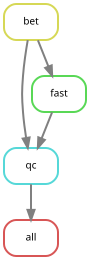

In [37]:
rg = subprocess.run(
    ['snakemake', '-s', 'workflow/Snakefile', '--rulegraph'],
    cwd=workdir, capture_output=True, text=True,
)
if rg.returncode != 0:
    print('--- stderr ---'); print(rg.stderr)
    raise RuntimeError('snakemake --rulegraph failed')

rg_svg = subprocess.run(
    ['dot', '-Tsvg'], input=rg.stdout, capture_output=True, text=True,
)

if rg_svg.returncode != 0:
    print('--- dot stderr ---')
    print(rg_svg.stderr)
    raise RuntimeError('dot failed; is graphviz installed?')
    
display(SVG(rg_svg.stdout))

**DAG** (one node per rule × subject job — Snakemake will execute 9 jobs total: 3 subjects × 3 rules):

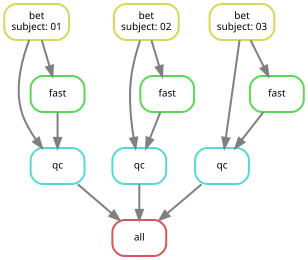

In [38]:
# Note: in Snakemake 9.x `--dag` takes an optional *format* argument (dot/mermaid-js),
# so we omit any target — Snakemake defaults to the first rule (`all`).
dag_result = subprocess.run(
    ['snakemake', '-s', 'workflow/Snakefile', '--dag'],
    cwd=workdir, capture_output=True, text=True,
)
if dag_result.returncode != 0:
    print('--- stderr ---')
    print(dag_result.stderr)
    raise RuntimeError('snakemake --dag failed; see stderr above')

dag_svg = subprocess.run(
    ['dot', '-Tsvg'],
    input=dag_result.stdout, capture_output=True, text=True,
)
if dag_svg.returncode != 0:
    print('--- dot stderr ---')
    print(dag_svg.stderr)
    raise RuntimeError('dot failed; is graphviz installed?')

display(SVG(dag_svg.stdout))

## 7. Dry-run the pipeline

Before committing real compute, `snakemake -n` (or `--dry-run`) walks the DAG and prints which jobs would be executed and why (missing output, updated input, changed input set, etc.) — without running anything. That makes it the fastest way to catch wildcard or path mismatches, unintended re-runs, or the wrong target list before they cost real compute. `--cores 4` is still required because Snakemake refuses to plan without a resource budget; nothing is actually scheduled.

In [39]:
result = subprocess.run(
    ['snakemake', '-s', 'workflow/Snakefile', '-n', '--cores', '4'],
    cwd=workdir, capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print('--- stderr ---')
    print(result.stderr)


SNAKEMAKE
  Date: 2026-07-02 00:57:40
  Workflow ID: 2f9a20a9-c5e8-4ccb-bad7-0e30ffa0fce9
  Platform: Linux-5.15.0-177-generic-x86_64-with-glibc2.39
  Host: jupyter-monidoerig
  User: jovyan
  Snakemake version: 9.23.0
  Python version: 3.13.13 | packaged by conda-forge | (main, Apr  8 2026, 02:00:33) [GCC 14.3.0]
  Command: /opt/conda/bin/snakemake -s workflow/Snakefile -n --cores 4
  Snakefile: /home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/snakemake_demo/workflow/Snakefile
  Base directory: /home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/snakemake_demo/workflow
  Run directory: /home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/snakemake_demo
  Working directory: /home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/snakemake_demo
  Config file(s): []
  Config MD5: 99914b932bd37a50b983c5e7c90ae93b

Building DAG of jobs...
Job stats:
job      count
-----  -------
bet          3
fast         3
qc           3
all 

## 8. Run the pipeline

Running with `--cores 4` lets Snakemake run up to four independent jobs in parallel on this machine — for this DAG that means BET on subject 01, 02, 03 all kicking off together. Expect a few minutes total: `bet` is fast (~10 s/subject), `fast` is the slower step (~2–3 min/subject).

We also pass `--keep-going` (`-k`) so a failure on one subject doesn't block the others. By default Snakemake stops on the first error — fine for debugging, but in a multi-subject run you usually want every independent branch of the DAG to make as much progress as possible before you investigate.

:::{important}
**Neurodesk-specific subshell tweak.** Snakemake's `--use-envmodules` spawns each rule in a non-interactive bash subshell to run `module purge && module load <X> && <your command>`. On Neurodesk, `module` is a **bash function** (not a binary on PATH) defined by Lmod's `/etc/profile.d/lmod.sh` — and non-interactive bash subshells don't source `/etc/profile.d/*` by default, so `module` is undefined and every rule fails.

Fix: set `BASH_ENV=/etc/profile.d/lmod.sh` in the environment we pass to Snakemake. Bash sources whatever `BASH_ENV` points to *before* running its command, so each rule's subshell will have `module` available. Without this, the rules fail with `module: command not found`.
:::


In [40]:
env = {**os.environ, 'BASH_ENV': '/etc/profile.d/lmod.sh'}

result = subprocess.run(
    ['snakemake', '-s', 'workflow/Snakefile', '--use-envmodules', '--cores', '4', '--keep-going'],
    cwd=workdir, env=env, capture_output=True, text=True,
)

print('return code:', result.returncode)
print('--- stderr (tail) ---')
print('\n'.join(result.stderr.splitlines()[-25:]))
if result.returncode != 0:
  print('--- stdout ---')
  print(result.stdout)

return code: 0
--- stderr (tail) ---

[Thu Jul  2 01:04:48 2026]
localrule qc:
    input: ds000114/sub-01/ses-test/anat/sub-01_ses-test_T1w.nii.gz, results/sub-01/anat/sub-01_desc-brain_T1w.nii.gz, results/sub-01/anat/sub-01_dseg.nii.gz
    output: results/sub-01/figures/sub-01_desc-qc.png
    jobid: 1
    reason: Missing output files: results/sub-01/figures/sub-01_desc-qc.png; Input files updated by another job: results/sub-01/anat/sub-01_desc-brain_T1w.nii.gz, results/sub-01/anat/sub-01_dseg.nii.gz
    wildcards: subject=01
    resources: tmpdir=/tmp, mem_mb=2000, mem=2 GB, mem_mib=1908
[Thu Jul  2 01:05:07 2026]
Finished jobid: 1 (Rule: qc)
9 of 10 steps (90%) done
Select jobs to execute...
Execute 1 jobs...

[Thu Jul  2 01:05:07 2026]
localrule all:
    input: results/sub-01/figures/sub-01_desc-qc.png, results/sub-02/figures/sub-02_desc-qc.png, results/sub-03/figures/sub-03_desc-qc.png
    jobid: 0
    reason: Input files updated by another job: results/sub-01/figures/sub-01_desc-q

:::{tip}
**Resumability.** If you delete or modify any output file (e.g. `results/sub-01/anat/sub-01_dseg.nii.gz`) and re-run the cell above, Snakemake detects the missing/changed file and only re-runs the rules that depend on it. This is a general property of caching workflow engines — Nipype, Pydra, and Nextflow all do the same thing under the hood, just with different mechanisms (input hashes for Nipype/Pydra, hash-keyed `work/` directories for Nextflow, file mtime for Snakemake by default). What's distinctive about Snakemake's version is its transparency of `snakemake -n` which tells you exactly which jobs would re-run and why (`reason: Missing output files: ...`, `reason: Input files updated by another job: ...`). That makes it easy to predict exactly which rules will re-fire before committing a long run.
:::




## 9. Inspect outputs

Snakemake placed each subject's QC PNG under `results/sub-XX/figures/`. We display each inline so we can eyeball whether BET + FAST worked as expected for each subject.

results/sub-01/figures/sub-01_desc-qc.png


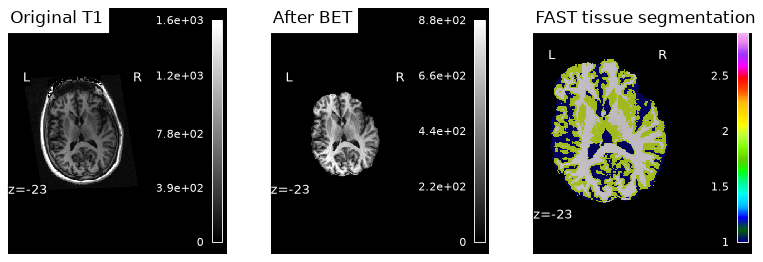

results/sub-02/figures/sub-02_desc-qc.png


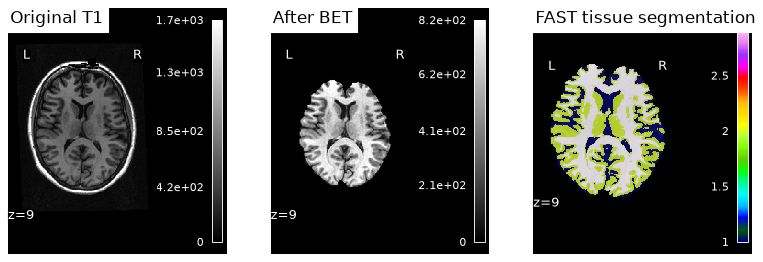

results/sub-03/figures/sub-03_desc-qc.png


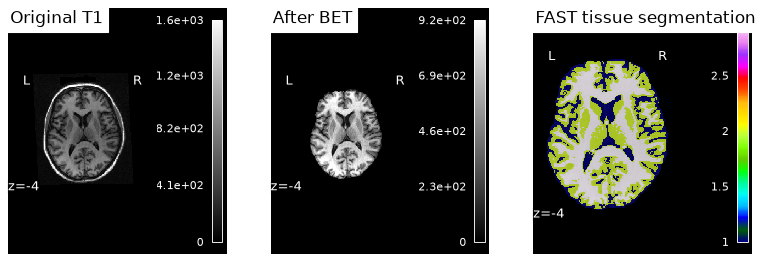

In [41]:
for png in sorted((workdir / 'results').glob('sub-*/figures/*.png')):
    print(png.relative_to(workdir))
    display(Image(filename=str(png)))

:::{note}
**Reading the third panel.** FAST assigns each brain voxel a discrete tissue class — typically rendered in three colours for CSF, gray matter, and white matter. A successful segmentation traces the cortical ribbon (a thin gray-matter band following gyri/sulci), with white matter as the bulkier interior structure and CSF marking the ventricles and the sulci between gyri. Mislabeled skull or empty patches inside the brain are signs that something went wrong upstream — most commonly a too-aggressive or too-conservative BET that left bone or removed cortex.
:::

## 10. Scaling beyond a notebook

Three natural next steps once your workflow is correct on a few subjects:

1. **More subjects on the same machine** — extend `SUBJECTS` in `common.smk` and bump `--cores`. Snakemake will parallelise up to that limit automatically.
2. **Cluster execution via SLURM** — the [snakemake-executor-plugin-slurm](https://github.com/snakemake/snakemake-executor-plugin-slurm) lets you submit each rule as its own `sbatch` job (`snakemake --executor slurm ...`). Combined with the per-rule    `envmodules:` and `resources:` directives this workflow already declares, every job loads exactly the modules it needs and asks SLURM for the right memory and threads on its assigned node — the *same workflow* runs locally and on the cluster.
3. **Containerise per rule:** If you eventually need to run this workflow off Neurodesk (laptops, CI, non-HPC clouds), see the [Snakemake deployment docs](https://snakemake.readthedocs.io/en/latest/snakefiles/deployment.html) for adding `conda:` or `container:` directives alongside `envmodules:`. Both can coexist on the same rule.

For an alternative scaling pattern using parameterised notebooks rather than a Snakefile, see [Papermill SLURM Job Submission](./papermill-slurm-submission-example.ipynb).

## Dependencies in Jupyter/Python
- Using the package [watermark](https://github.com/rasbt/watermark) to document system environment and software versions used in this notebook, alongside the Neurodesktop version extracted from the `JUPYTER_IMAGE` or `NEURODESKTOP_VERSION` environment variables.

In [42]:
%load_ext watermark

%watermark
%watermark --iversions

neurodesktop_version = (
    os.environ.get('JUPYTER_IMAGE', '').split(':')[-1] or
    os.environ.get('NEURODESKTOP_VERSION', 'unknown')
)

print(f"Neurodesktop version: {neurodesktop_version}")

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: 2026-07-02T01:05:10.392260+00:00

Python implementation: CPython
Python version       : 3.13.13
IPython version      : 9.12.0

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 5.15.0-177-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 30
Architecture: 64bit

IPython   : 9.12.0
bids      : 0.22.0
matplotlib: 3.11.0
nibabel   : 5.4.2
nilearn   : 0.13.1
numpy     : 2.4.6

Neurodesktop version: 2026-06-13
